<a href="https://colab.research.google.com/github/qcx201/colab/blob/master/colab_unemployment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Job search economics

Test

I've started the job search process. I see all these Reddit posts about people who have applied to some insane number of jobs, some claiming to have sent in hundreds of applications without receiving an offer.

As a simple example, say you're chances at getting any specific job are $p$. Let's assume the probabilities are independent, since your outcomes in one job application shouldn't influence your outcomes in another, if word doesn't get around.

The chances that you will get a job after $n$ applications is given by
$$q = 1 - (1-p)^n.$$

Let's see your probabilities of getting a job $q$ with different values $p$ to $n$.

The more general form is this,
$$\begin{align}
E[q] = 1 - \prod_{i=1}^n (1-p),
\end{align}$$
where $p = E[p_i]$ is the expected probability of success for each application $i$ as a random variable, assuming $p_i$'s are independent.

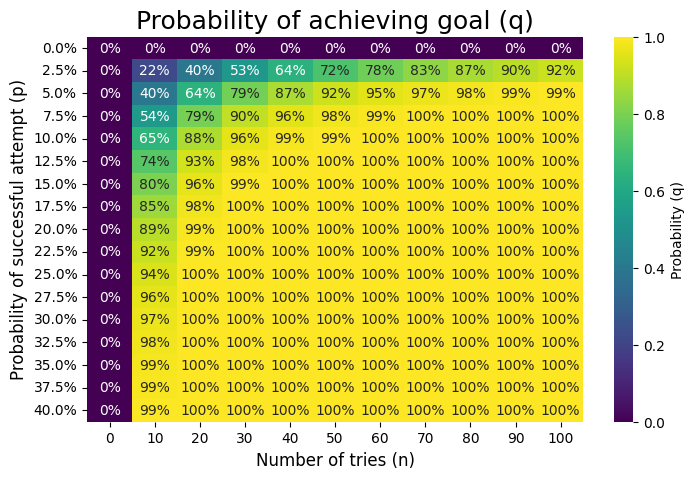

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

p = np.arange(0, 0.41, 0.025)
n = np.arange(0, 101, 10)
q = 1 - ((1 - p[:, np.newaxis])**n[np.newaxis, :])

# Create a DataFrame with rounded index for cleaner y-axis labels

dfq = pd.DataFrame(q, index=map(lambda x : f'{x:.1%}', p), columns=n)

plt.figure(figsize=(8, 5))
# Use seaborn heatmap and set annot=True to label the q values in the cells
sns.heatmap(dfq, annot=True, fmt=".0%", cmap="viridis", cbar_kws={'label': 'Probability (q)'})

plt.xlabel('Number of tries (n)', fontsize=12)
plt.ylabel('Probability of successful attempt (p)', fontsize=12)
plt.title('Probability of achieving goal (q)', fontsize=18)
plt.show()

Interesting that you see this non-linear relationship between $p$ and $n$. You can solve for $n$ with

$$
\begin{align}
q
= 1 - (1-p)^n
&\implies
(1-p)^n = 1-q
\\&\implies
n \log(1-p) = \log(1-q)
\\&\implies
n = \frac{\log(1-q)}{\log(1-p)}
\end{align}
$$

Now let's plot this relationship for various values of $q$ sucessful job search. These are the **isoquants** of job search.

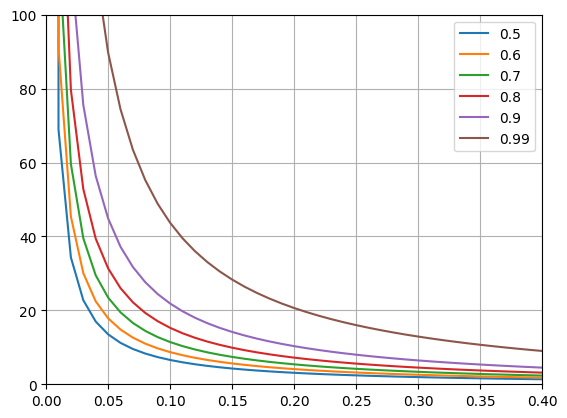

In [ ]:
fig, ax = plt.subplots()

p = np.linspace(0.01, 0.40, 40)
p = np.append(1e-10, p)

qs = np.linspace(0.5, 0.9, 5)
qs = np.append(qs, 0.99)

for q in qs:
    n = np.log(1 - q) / np.log(1 - p)
    ax.plot(p, n, label=q)

ax.set_ylim(0, 100)
ax.set_xlim(0, p.max())

ax.legend()
ax.grid()

plt.show()

To achieve a 90% probability of finding a job, with under 20 applications you need just a little above a 10% success rate for each application. Whereas if you need have only a 5% success rate, you need to apply to about 50 jobs.

What is the implied success rate of somebody who has applied to 100 jobs, given a 90% chance that they land one?

That's given by
$$\begin{align}
p
&= 1-(1-q)^{1/n}
\\
&= 1-(1-0.9)^{1/100}
\\
&\simeq 2.28\%
\end{align}$$

All in all, it's much better if you can increase your chances from 2% to 10%, requiring only applying to 20 jobs instead of 100 for the same results.

In [ ]:
n = 100
q = 0.9
p = 1 - (1-q)**(1/n)
print(f'{p:.2%}')

2.28%


### Optimizing the Quality vs. Quantity Trade-off

To find the optimal strategy, let's assume you have a fixed time budget $T$.

The time it takes to complete one application is a function of its quality: $c(p)$.
- A "quick apply" might take 1 hour but yield a low $p$ (e.g., 2%).
- A highly tailored application might take 5 hours, significantly increasing $p$ (e.g., 10%).

Let's model the cost function as $c(p) = 1 + k \cdot p^2$, meaning it takes exponentially more time to squeeze out higher probabilities of success.

The total applications you can send is $n = \frac{T}{c(p)}$. We can substitute this into our original equation to find the overall probability $q$ as a function of $p$, given your time limit:
$$q(p) = 1 - (1-p)^{\frac{T}{c(p)}}$$

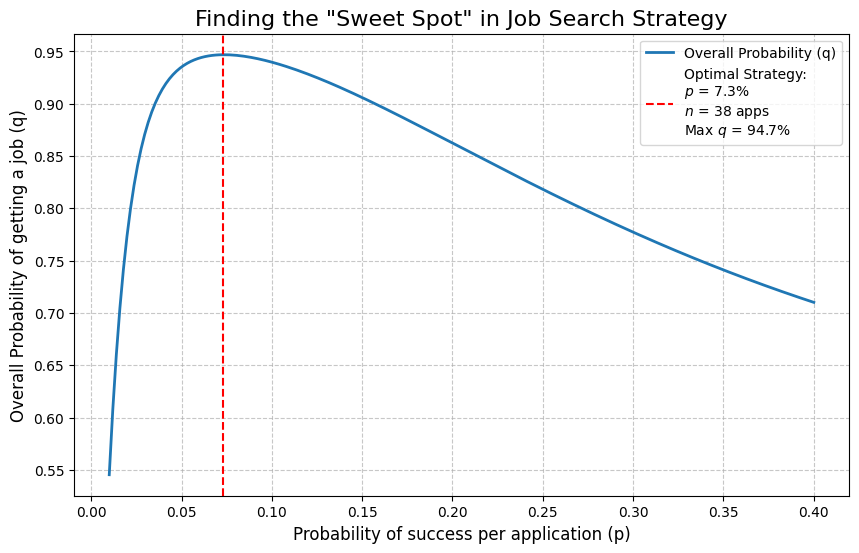

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Total time available for the job search (e.g., hours)
T = 80

# Array of possible success rates per application
p_array = np.linspace(0.01, 0.40, 200)

# Hypothetical time cost function: base 1 hour + increasing time for higher 'p'
# Example: 1 hour for p=0, ~3 hours for p=10%, ~9 hours for p=20%
k = 200
time_per_app = 1 + k * (p_array ** 2)

# Calculate how many applications we can send with our time budget
n_array = T / time_per_app

# Calculate overall probability of at least one job offer
q_array = 1 - (1 - p_array)**n_array

# Find the optimal 'p' that maximizes 'q'
optimal_idx = np.argmax(q_array)
optimal_p = p_array[optimal_idx]
max_q = q_array[optimal_idx]
optimal_n = n_array[optimal_idx]

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(p_array, q_array, label='Overall Probability (q)', linewidth=2)
plt.axvline(optimal_p, color='red', linestyle='--',
            label=f'Optimal Strategy:\n$p$ = {optimal_p:.1%}\n$n$ = {int(optimal_n)} apps\nMax $q$ = {max_q:.1%}')

plt.xlabel('Probability of success per application (p)', fontsize=12)
plt.ylabel('Overall Probability of getting a job (q)', fontsize=12)
plt.title('Finding the "Sweet Spot" in Job Search Strategy', fontsize=16)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()